# Multivariate Analysis of Expected UK/US IRD (Proxied Using 2Y Bond Yield) Against GBP/USD

In [318]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Processing

### Load Data

In [319]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
gbpusd = pd.read_csv("../data/features/gbpusd/v1_11-09-25/gbpusd_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [320]:
gbpusd.head()

,gbp_usd_noon_rate,simple_return,log_return
date,,,
1971-01-04,2.3938,NaN,NaN
1971-01-05,2.3949,0.000460,0.000459
1971-01-06,2.3967,0.000752,0.000751
1971-01-07,2.3963,-0.000167,-0.000167
1971-01-08,2.3972,0.000376,0.000376


In [321]:
# Load dtype map
dtype_map = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_dtypes_as_of_110925.csv").to_dict()

# Convert dtype strings to actual Python types
dtype_map = {
    col: eval(dtype_str) if "float" in dtype_str or "int" in dtype_str else "object"
    for col, dtype_str in dtype_map.items()
}

# Load cleaned data with correct types
spread = pd.read_csv("../data/features/spread/v1_11-09-25/spread_features_as_of_110925.csv", dtype=dtype_map, parse_dates=[0], index_col=0)

In [322]:
spread.head()

,uk_2y,us_2y,spread_bp,spread_abs_change_daily,spread_bp_z_score,spread_abs_change_daily_z_score
date,,,,,,
1979-01-01,11.96,9.98,198.0,NaN,NaN,NaN
1979-01-02,11.96,10.00,196.0,-2.0,NaN,NaN
1979-01-03,11.99,9.98,201.0,5.0,NaN,NaN
1979-01-04,11.94,9.88,206.0,5.0,NaN,NaN
1979-01-05,11.89,9.87,202.0,-4.0,NaN,NaN


### Alignment

In [323]:
start = max(gbpusd.index.min(), spread.index.min())
end   = min(gbpusd.index.max(), spread.index.max())
calendar = pd.date_range(start=start, end=end, freq="B")

In [324]:
gbpusd = gbpusd.reindex(calendar)
spread = spread.reindex(calendar)

In [325]:
print(gbpusd["gbp_usd_noon_rate"].isna().sum())
print(spread["spread_bp"].isna().sum())

0
0


### Lags

In [326]:
spread["30d_lagged_spread_bp"] = spread["spread_bp"].shift(30)
spread["7d_lagged_spread_bp"] = spread["spread_bp"].shift(7)
spread["1d_lagged_spread_bp"] = spread["spread_bp"].shift(1)
spread.head()

,uk_2y,us_2y,spread_bp,spread_abs_change_daily,spread_bp_z_score,spread_abs_change_daily_z_score,30d_lagged_spread_bp,7d_lagged_spread_bp,1d_lagged_spread_bp
1979-01-01,11.96,9.98,198.0,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-02,11.96,10.00,196.0,-2.0,NaN,NaN,NaN,NaN,198.0
1979-01-03,11.99,9.98,201.0,5.0,NaN,NaN,NaN,NaN,196.0
1979-01-04,11.94,9.88,206.0,5.0,NaN,NaN,NaN,NaN,201.0
1979-01-05,11.89,9.87,202.0,-4.0,NaN,NaN,NaN,NaN,206.0


### Z-Score

In [327]:
spread["spread_z_score"] = (spread["spread_bp"] - spread["spread_bp"].mean()) / spread["spread_bp"].std()
gbpusd["price_z_score"] = (gbpusd["gbp_usd_noon_rate"] - gbpusd["gbp_usd_noon_rate"].mean()) / gbpusd["gbp_usd_noon_rate"].std()

In [328]:
spread["610d_spread_z_score"] = spread["spread_z_score"].shift(610)
spread["365d_spread_z_score"] = spread["spread_z_score"].shift(365)
spread["90d_spread_z_score"] = spread["spread_z_score"].shift(90)

## Analysis : UK-US 2Y Spread (bp) vs GBP/USD Log Returns

### Plots

Text(0, 0.5, 'Log Returns')

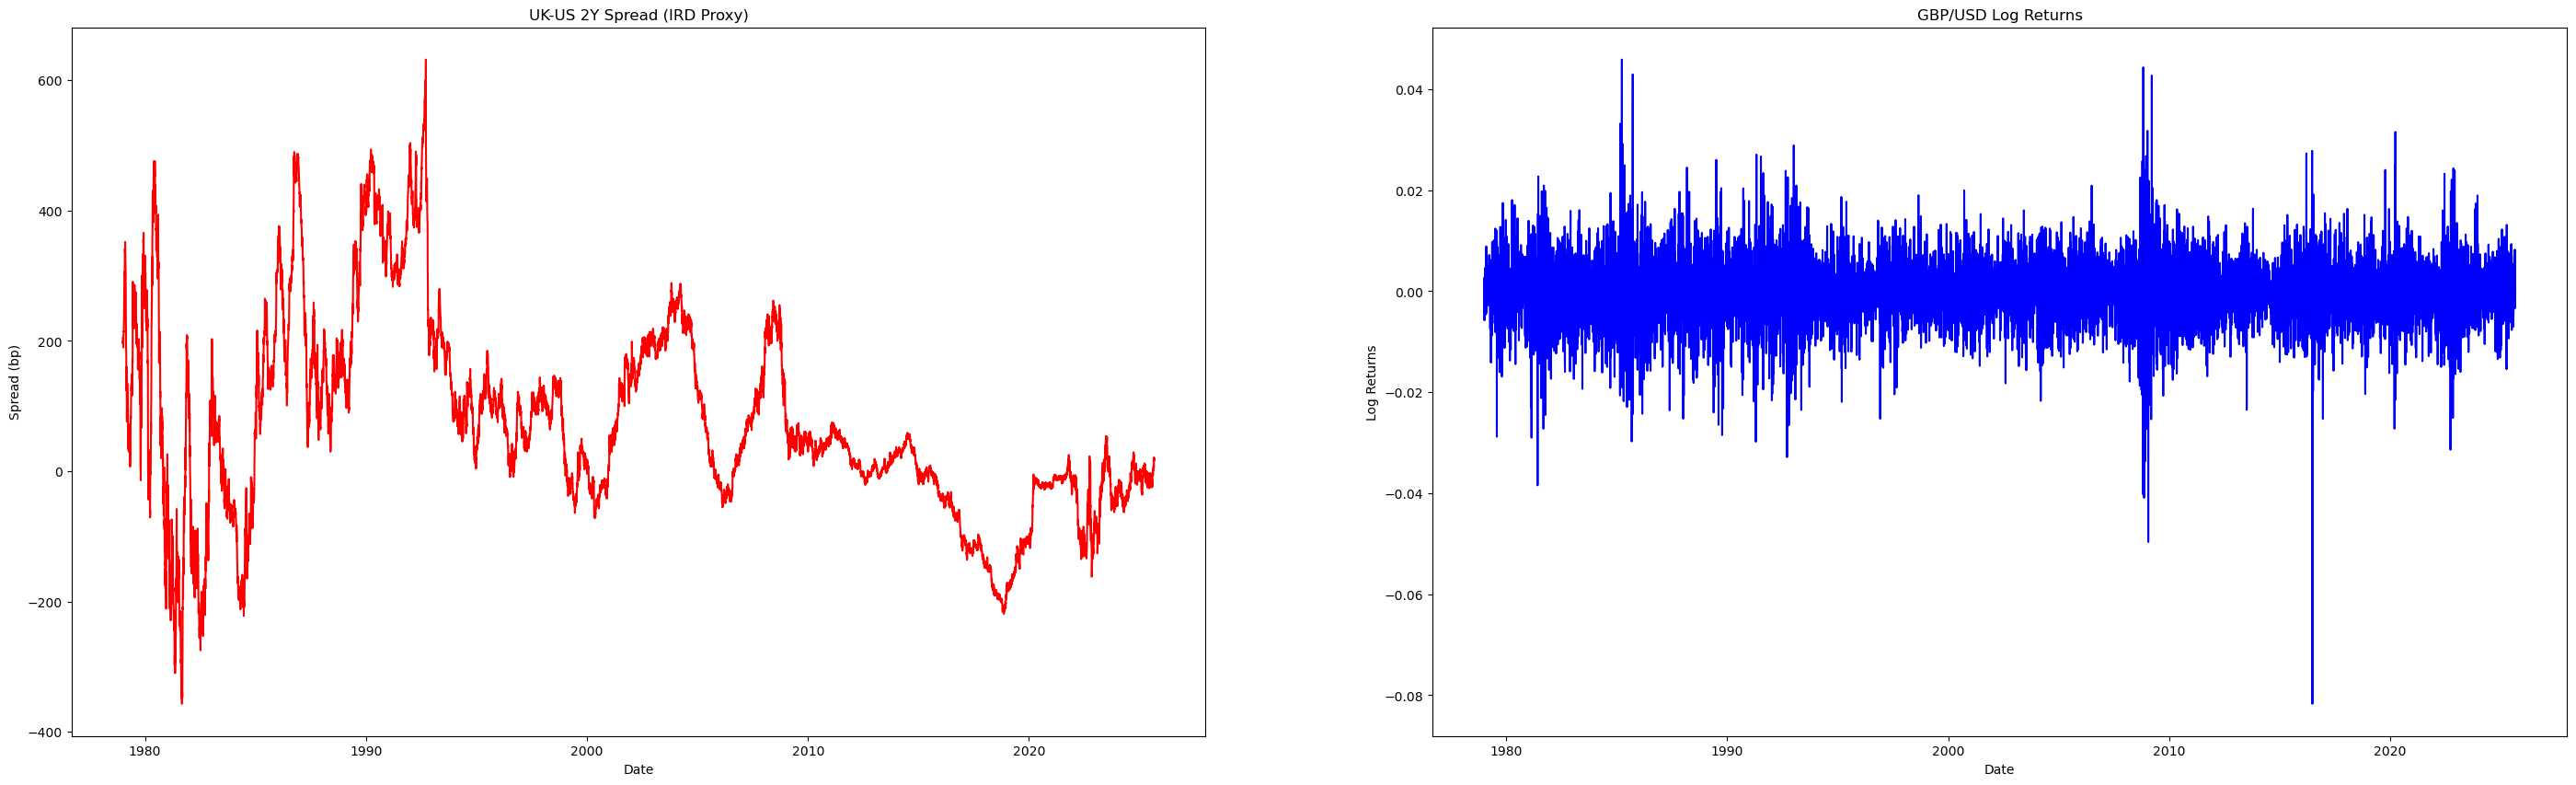

In [329]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread (IRD Proxy)", fontsize=12)
axs[0].plot(spread["spread_bp"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Spread (bp)")

axs[1].set_title("GBP/USD Log Returns", fontsize=12)
axs[1].plot(gbpusd["log_return"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Log Returns")

### Regressions

In [330]:
X = sm.add_constant(spread["spread_bp"])
y = gbpusd["log_return"]

model = sm.OLS(y, X)
contemporaneous_regression = model.fit()

contemporaneous_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.33
Date:                Sun, 26 Oct 2025   Prob (F-statistic):           0.000763
Time:                        14:02:37   Log-Likelihood:                 44889.
No. Observations:               12175   AIC:                        -8.977e+04
Df Residuals:                   12173   BIC:                        -8.976e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001   6.08e-05     -1.999      0.046      -0.000   -2.35e-06
spread_bp   1.223e-06   3.63e-07      3.367      0.001    5.11e-07    1.94e-06
==============================================================================
Omnibus:                     1845.874   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21833.025
Skew:                          -0.337   Prob(JB):                         0.00
Kurtosis:                       9.526   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [331]:
X = sm.add_constant(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()])
y = gbpusd["log_return"][spread["30d_lagged_spread_bp"].notna()]

model = sm.OLS(y, X)
thirty_day_regression = model.fit()

thirty_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.909
Date:                Sun, 26 Oct 2025   Prob (F-statistic):             0.0881
Time:                        14:02:37   Log-Likelihood:                 44764.
No. Observations:               12145   AIC:                        -8.952e+04
Df Residuals:                   12143   BIC:                        -8.951e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -7.694e-05   6.09e-05     -1.263      0.207      -0.000    4.25e-05
30d_lagged_spread_bp  6.205e-07   3.64e-07      1.705      0.088   -9.27e-08    1.33e-06
==============================================================================
Omnibus:                     1831.189   Durbin-Watson:                   1.919
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21632.296
Skew:                          -0.332   Prob(JB):                         0.00
Kurtosis:                       9.504   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [332]:
X = sm.add_constant(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()])
y = gbpusd["log_return"][spread["7d_lagged_spread_bp"].notna()]

model = sm.OLS(y, X)
seven_day_regression = model.fit()

seven_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     5.877
Date:                Sun, 26 Oct 2025   Prob (F-statistic):             0.0154
Time:                        14:02:38   Log-Likelihood:                 44858.
No. Observations:               12168   AIC:                        -8.971e+04
Df Residuals:                   12166   BIC:                        -8.970e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -9.612e-05   6.08e-05     -1.580      0.114      -0.000    2.31e-05
7d_lagged_spread_bp  8.812e-07   3.63e-07      2.424      0.015    1.69e-07    1.59e-06
==============================================================================
Omnibus:                     1838.686   Durbin-Watson:                   1.919
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21751.581
Skew:                          -0.333   Prob(JB):                         0.00
Kurtosis:                       9.516   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [333]:
X = sm.add_constant(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()])
y = gbpusd["log_return"][spread["1d_lagged_spread_bp"].notna()]

model = sm.OLS(y, X)
one_day_regression = model.fit()

one_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     9.302
Date:                Sun, 26 Oct 2025   Prob (F-statistic):            0.00229
Time:                        14:02:38   Log-Likelihood:                 44884.
No. Observations:               12174   AIC:                        -8.976e+04
Df Residuals:                   12172   BIC:                        -8.975e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0001   6.08e-05     -1.863      0.062      -0.000    5.89e-06
1d_lagged_spread_bp  1.108e-06   3.63e-07      3.050      0.002    3.96e-07    1.82e-06
==============================================================================
Omnibus:                     1843.959   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21811.023
Skew:                          -0.336   Prob(JB):                         0.00
Kurtosis:                       9.523   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Correlation

Text(0, 0.5, 'Correlation')

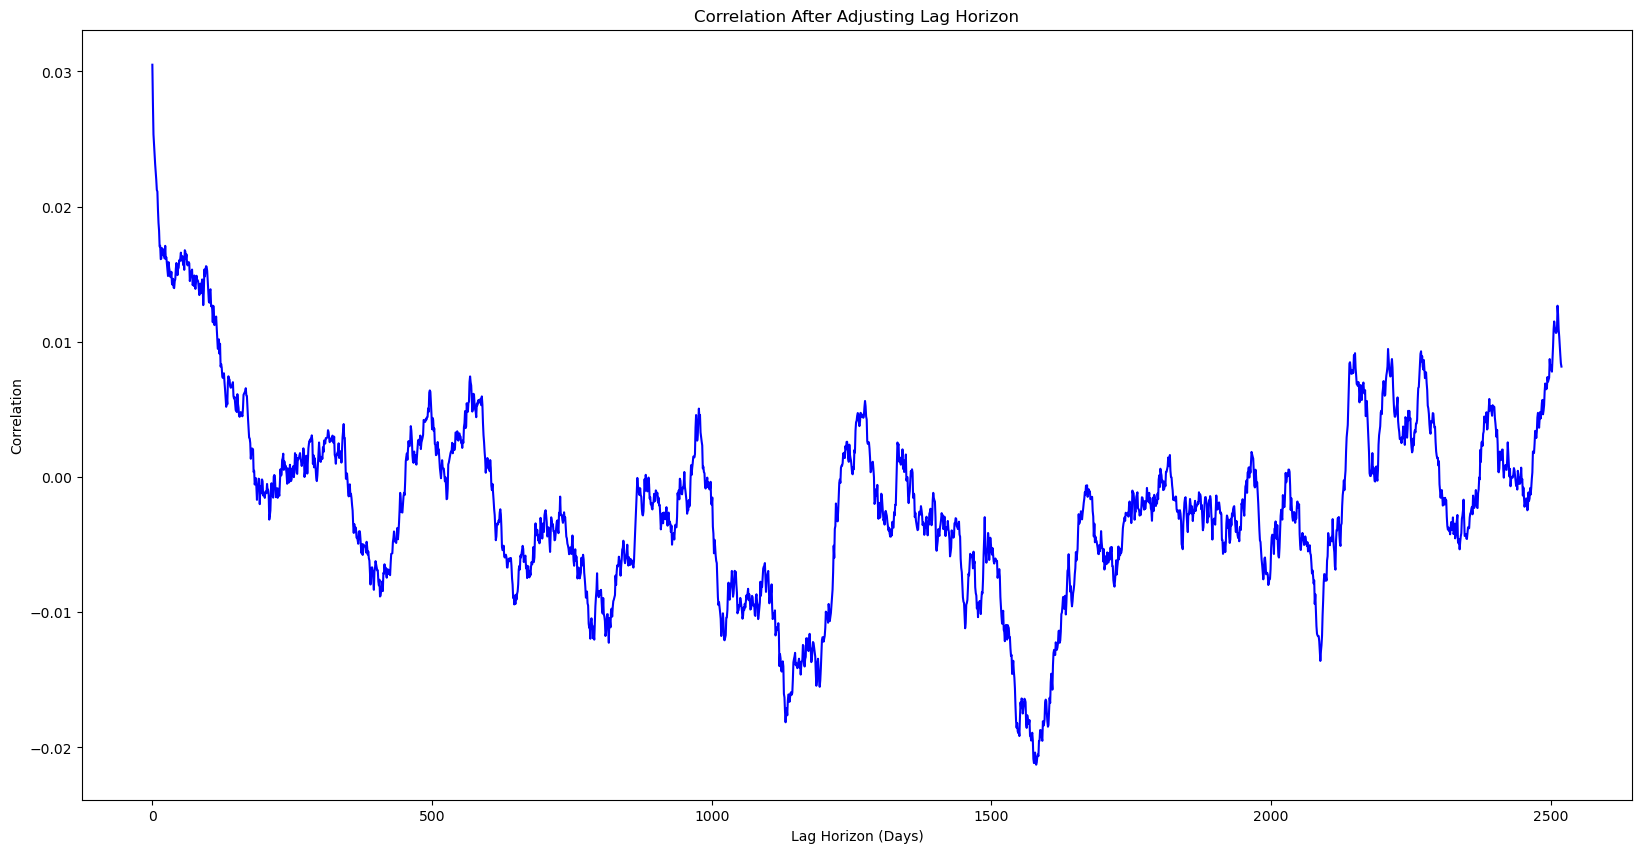

In [334]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread["spread_bp"].shift(h).corr(gbpusd["log_return"]) for h in range(0, 252 * 10)}
)

fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

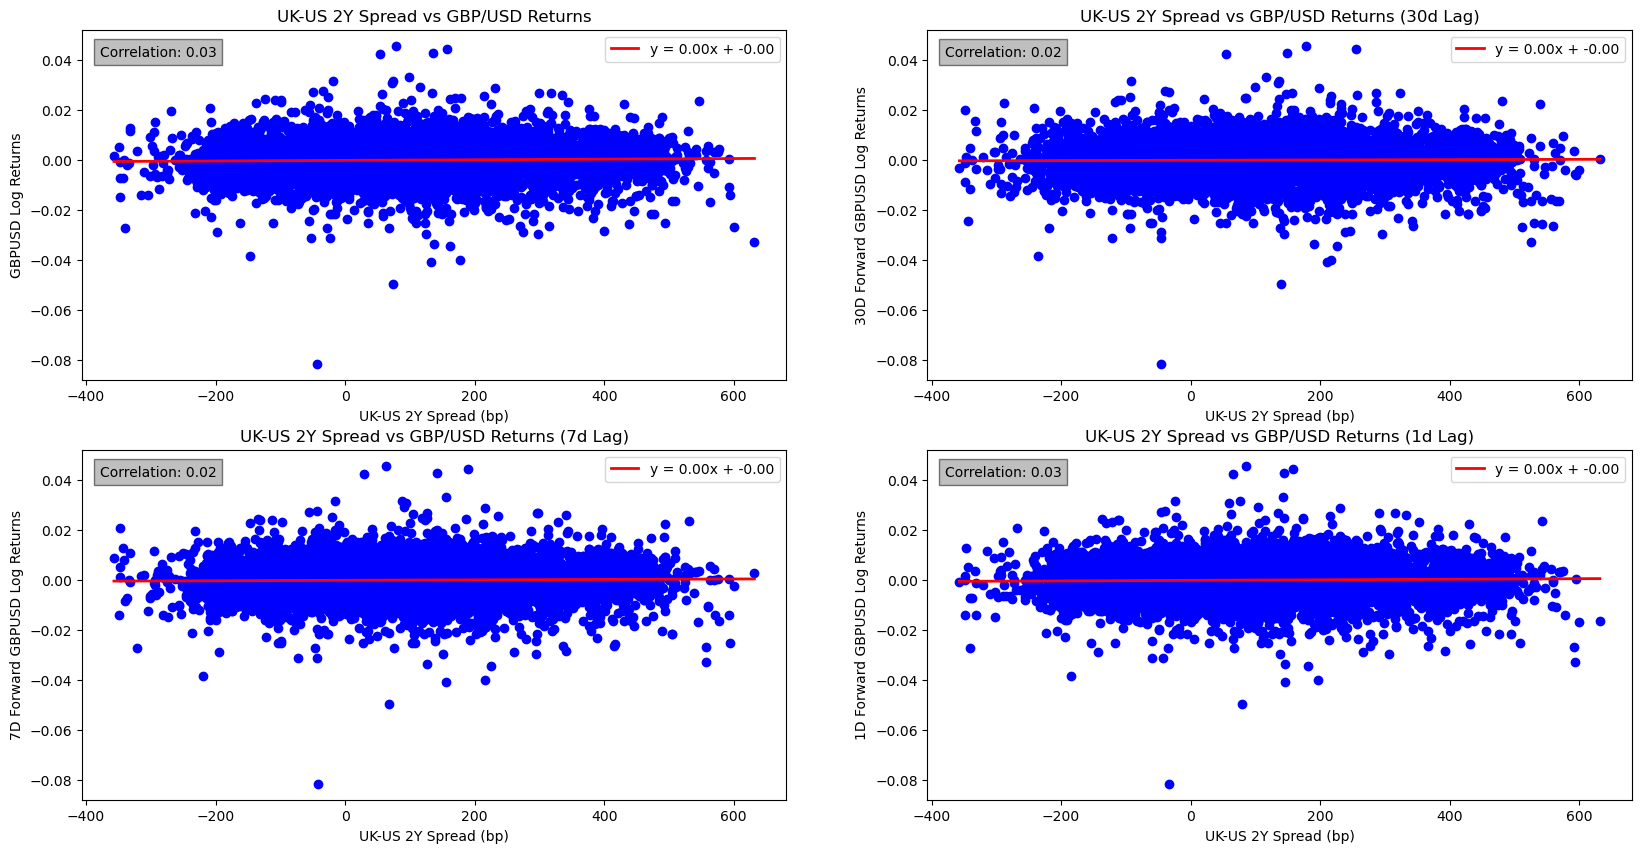

In [335]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

# Spread vs Returns
axs[0, 0].set_title("UK-US 2Y Spread vs GBP/USD Returns", fontsize=12)
axs[0, 0].scatter(spread["spread_bp"], gbpusd["log_return"], color="blue")

axs[0, 0].set_xlabel("UK-US 2Y Spread (bp)")
axs[0, 0].set_ylabel("GBPUSD Log Returns")

x_line = np.linspace(min(spread["spread_bp"]), max(spread["spread_bp"]), 100)
y_line = contemporaneous_regression.params.iloc[0] + contemporaneous_regression.params.iloc[1] * x_line
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {contemporaneous_regression.params.iloc[1]:.2f}x + {contemporaneous_regression.params.iloc[0]:.2f}")

corr = spread["spread_bp"].corr(gbpusd["log_return"])
axs[0, 0].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[0, 0].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[0, 0].legend()

# Spread vs 30d Forward Returns
axs[0, 1].set_title("UK-US 2Y Spread vs GBP/USD Returns (30d Lag)", fontsize=12)
axs[0, 1].scatter(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["30d_lagged_spread_bp"].notna()], color="blue")

axs[0, 1].set_xlabel("UK-US 2Y Spread (bp)")
axs[0, 1].set_ylabel("30D Forward GBPUSD Log Returns")

x_line = np.linspace(min(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()]), max(spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()]), 100)
y_line = thirty_day_regression.params.iloc[0] + thirty_day_regression.params.iloc[1] * x_line
axs[0, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {thirty_day_regression.params.iloc[1]:.2f}x + {thirty_day_regression.params.iloc[0]:.2f}")

corr = spread["30d_lagged_spread_bp"][spread["30d_lagged_spread_bp"].notna()].corr(gbpusd["log_return"][spread["30d_lagged_spread_bp"].notna()])
axs[0, 1].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[0, 1].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[0, 1].legend()

# Spread vs 7d Forward Returns
axs[1, 0].set_title("UK-US 2Y Spread vs GBP/USD Returns (7d Lag)", fontsize=12)
axs[1, 0].scatter(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["7d_lagged_spread_bp"].notna()], color="blue")

axs[1, 0].set_xlabel("UK-US 2Y Spread (bp)")
axs[1, 0].set_ylabel("7D Forward GBPUSD Log Returns")

x_line = np.linspace(min(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()]), max(spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()]), 100)
y_line = seven_day_regression.params.iloc[0] + seven_day_regression.params.iloc[1] * x_line
axs[1, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {seven_day_regression.params.iloc[1]:.2f}x + {seven_day_regression.params.iloc[0]:.2f}")

corr = spread["7d_lagged_spread_bp"][spread["7d_lagged_spread_bp"].notna()].corr(gbpusd["log_return"][spread["7d_lagged_spread_bp"].notna()])
axs[1, 0].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[1, 0].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[1, 0].legend()

# Spread vs 1d Forward Returns
axs[1, 1].set_title("UK-US 2Y Spread vs GBP/USD Returns (1d Lag)", fontsize=12)
axs[1, 1].scatter(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()], gbpusd["log_return"][spread["1d_lagged_spread_bp"].notna()], color="blue")

axs[1, 1].set_xlabel("UK-US 2Y Spread (bp)")
axs[1, 1].set_ylabel("1D Forward GBPUSD Log Returns")

x_line = np.linspace(min(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()]), max(spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()]), 100)
y_line = one_day_regression.params.iloc[0] + one_day_regression.params.iloc[1] * x_line
axs[1, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {one_day_regression.params.iloc[1]:.2f}x + {one_day_regression.params.iloc[0]:.2f}")

corr = spread["1d_lagged_spread_bp"][spread["1d_lagged_spread_bp"].notna()].corr(gbpusd["log_return"][spread["1d_lagged_spread_bp"].notna()])
axs[1, 1].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[1, 1].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[1, 1].legend()

### Analysis, Conclusion & Next Steps

- Basically I'm asking: “Does yesterday’s rate differential explain today’s tick-to-tick FX noise?”. The answer, unsurprisingly, is “not really.”
- Daily FX returns are dominated by noise — microstructure effects, flows, sentiment, liquidity conditions — none of which are directly related to slow-moving rate differentials.
- I also suspect that here may be some scale distortion as the variance of the spread decreases over time and is non-stationary.

**Next Steps**
- Try lengthening the return horizon. Compute rolling FX returns over the next 1-week, 1-month, or even 3-month periods. The longer horizon lets the slower-moving rate differential exert influence.
- Try using z-score of Uk-US 2Y as independent.


## Analysis : UK-US 2Y Spread Z-Score vs GBP/USD Z-Score

### Plots

Text(0, 0.5, 'Z-Score')

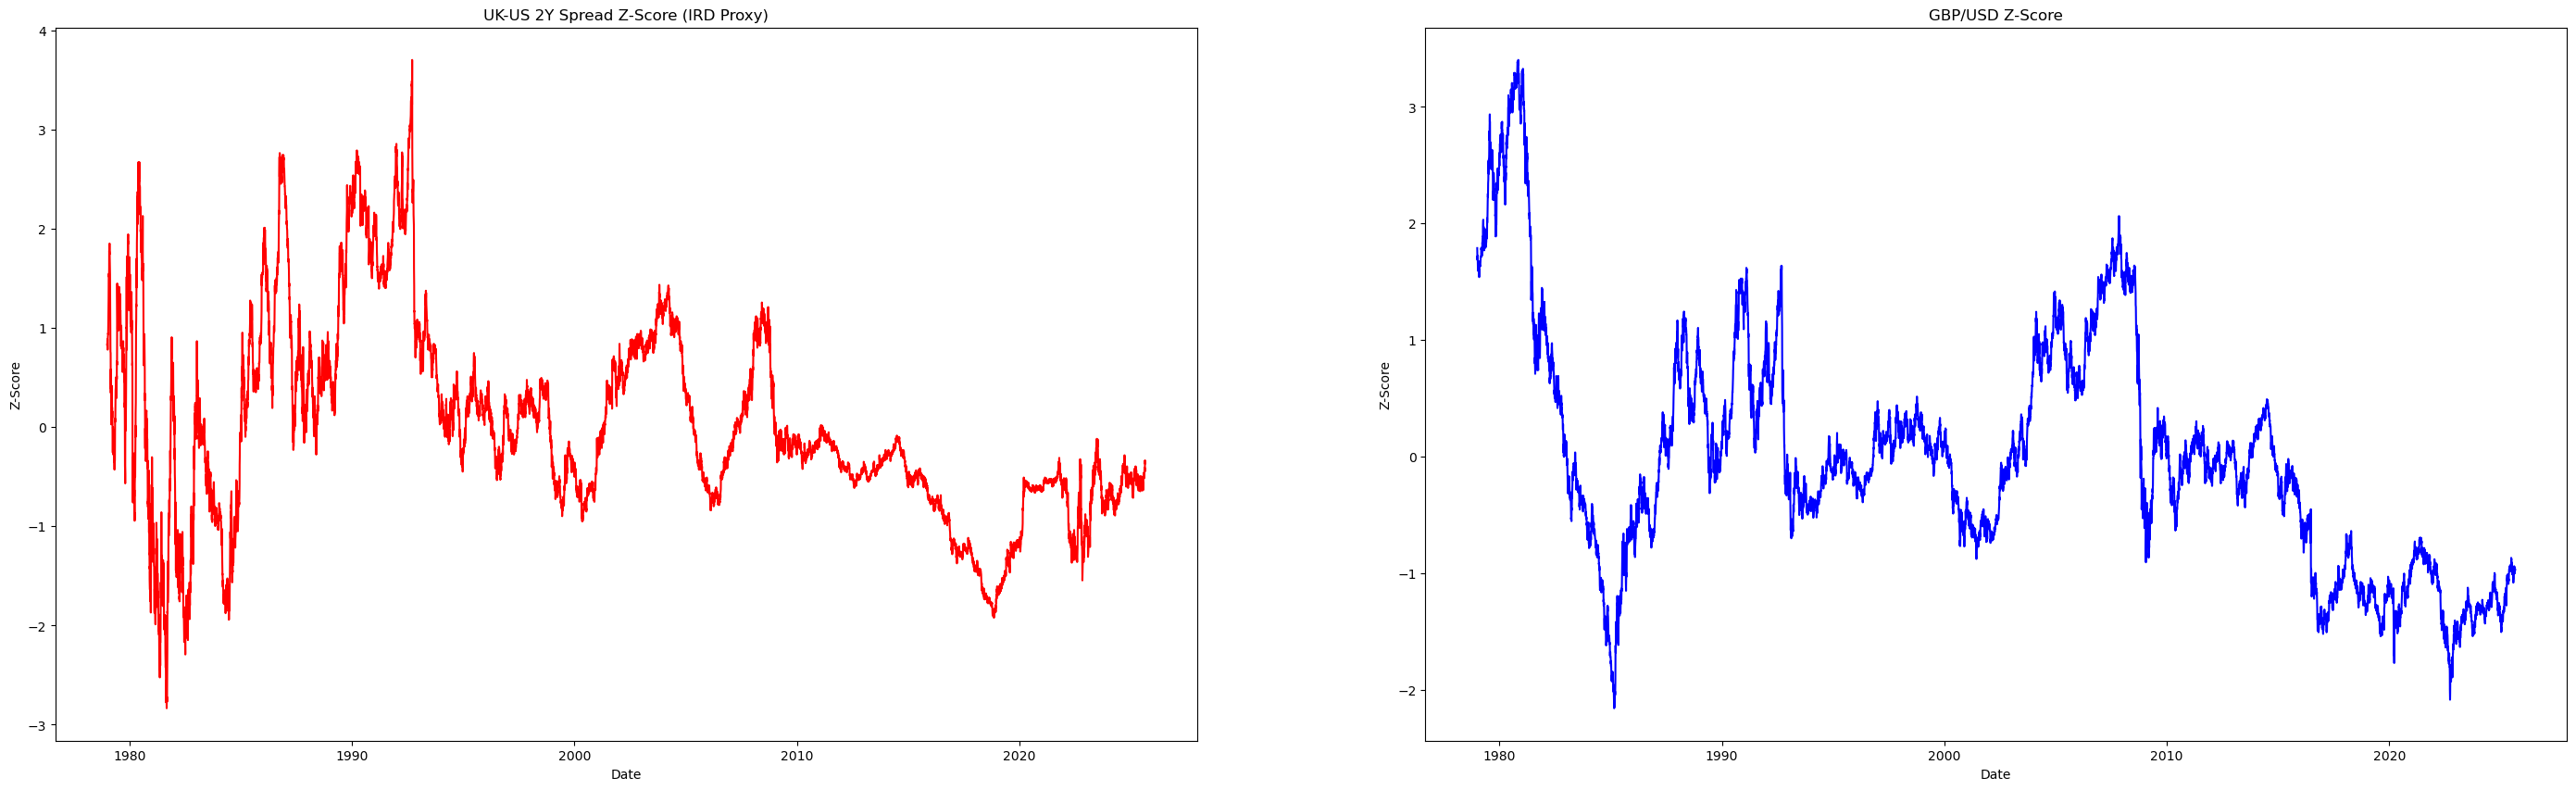

In [336]:
fig, axs = plt.subplots(1, 2, figsize=(35, 10))

axs[0].set_title("UK-US 2Y Spread Z-Score (IRD Proxy)", fontsize=12)
axs[0].plot(spread["spread_z_score"], color="red")

axs[0].set_xlabel("Date")
axs[0].set_ylabel("Z-Score")

axs[1].set_title("GBP/USD Z-Score", fontsize=12)
axs[1].plot(gbpusd["price_z_score"], color="blue")

axs[1].set_xlabel("Date")
axs[1].set_ylabel("Z-Score")

### Regressions

In [337]:
X = sm.add_constant(spread["spread_z_score"][spread["spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["spread_z_score"].notna()]

model = sm.OLS(y, X)
contemporaneous_regression = model.fit()

contemporaneous_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1983.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:02:40   Log-Likelihood:                -16356.
No. Observations:               12175   AIC:                         3.272e+04
Df Residuals:                   12173   BIC:                         3.273e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.464e-16      0.008   4.12e-14      1.000      -0.016       0.016
spread_z_score     0.3743      0.008     44.535      0.000       0.358       0.391
==============================================================================
Omnibus:                     2130.068   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3986.499
Skew:                           1.091   Prob(JB):                         0.00
Kurtosis:                       4.759   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [338]:
X = sm.add_constant(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()]

model = sm.OLS(y, X)
six10_day_regression = model.fit()

six10_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     4550.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:02:41   Log-Likelihood:                -12253.
No. Observations:               11565   AIC:                         2.451e+04
Df Residuals:                   11563   BIC:                         2.453e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1474      0.006    -22.700      0.000      -0.160      -0.135
610d_spread_z_score     0.4309      0.006     67.452      0.000       0.418       0.443
==============================================================================
Omnibus:                      334.286   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              365.779
Skew:                           0.416   Prob(JB):                     3.73e-80
Kurtosis:                       3.260   Cond. No.                         1.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [339]:
X = sm.add_constant(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()]

model = sm.OLS(y, X)
three65_day_regression = model.fit()

three65_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     3633.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:02:41   Log-Likelihood:                -14310.
No. Observations:               11810   AIC:                         2.862e+04
Df Residuals:                   11808   BIC:                         2.864e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0775      0.007    -10.360      0.000      -0.092      -0.063
365d_spread_z_score     0.4464      0.007     60.273      0.000       0.432       0.461
==============================================================================
Omnibus:                     2230.479   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4809.821
Skew:                           1.102   Prob(JB):                         0.00
Kurtosis:                       5.216   Cond. No.                         1.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [340]:
X = sm.add_constant(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()])
y = gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()]

model = sm.OLS(y, X)
ninety_day_regression = model.fit()

ninety_day_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_z_score   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     2785.
Date:                Sun, 26 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:02:41   Log-Likelihood:                -15799.
No. Observations:               12085   AIC:                         3.160e+04
Df Residuals:                   12083   BIC:                         3.162e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0148      0.008     -1.817      0.069      -0.031       0.001
90d_spread_z_score     0.4283      0.008     52.769      0.000       0.412       0.444
==============================================================================
Omnibus:                     2059.322   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3512.307
Skew:                           1.121   Prob(JB):                         0.00
Kurtosis:                       4.397   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Correlation

Text(0, 0.5, 'Correlation')

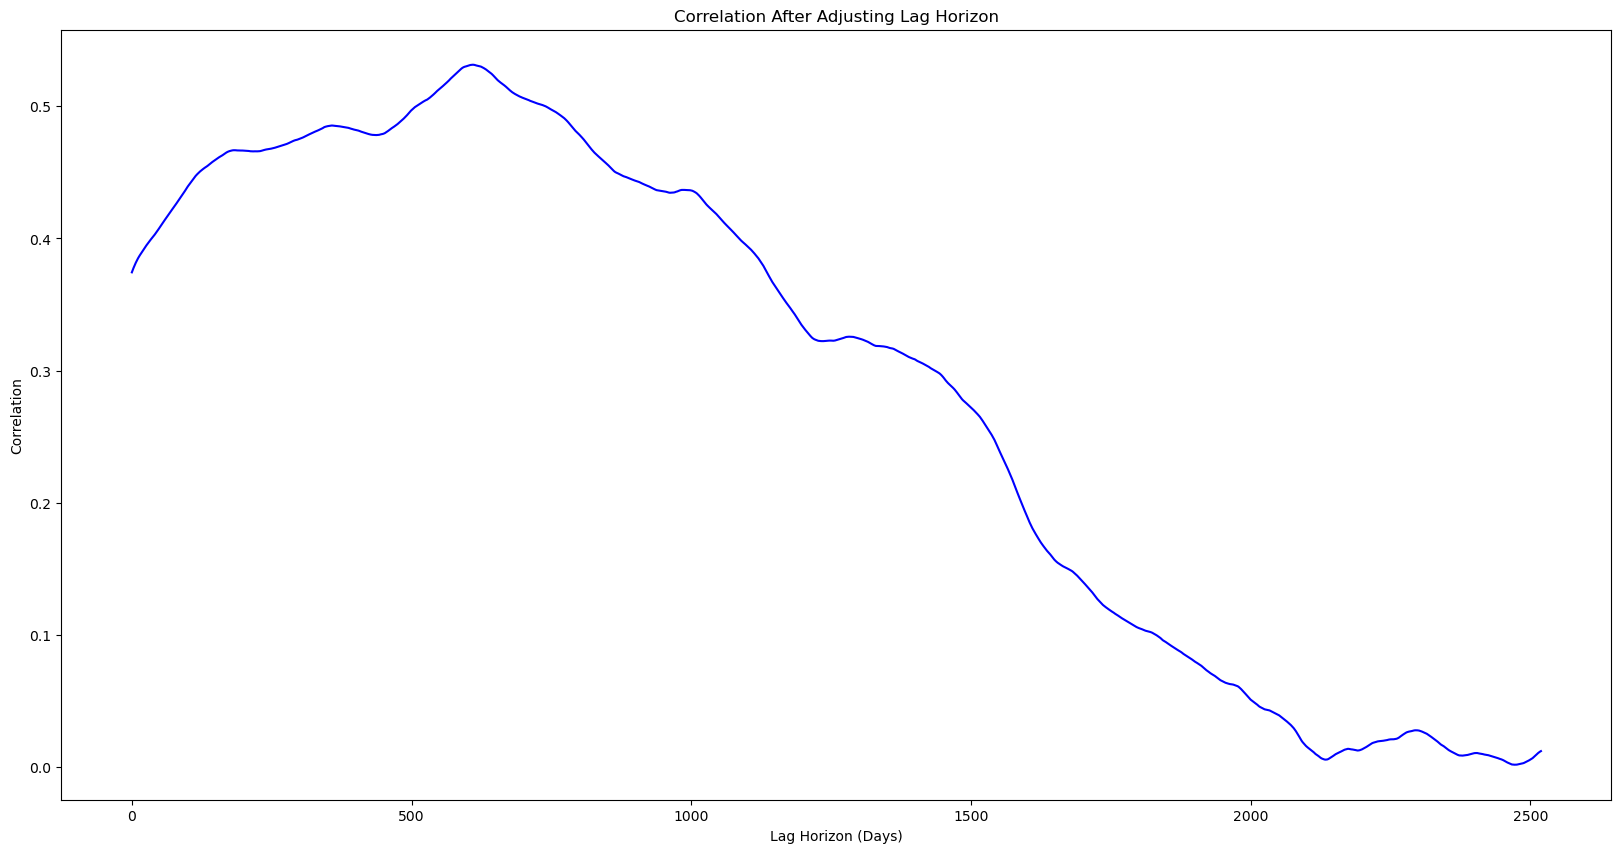

In [341]:
correlation_varying_lag_time_horizon = pd.Series(
    {h: spread["spread_z_score"].shift(h).corr(gbpusd["price_z_score"]) for h in range(0, 252 * 10)}
)

fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("Correlation After Adjusting Lag Horizon", fontsize=12)
axs.plot(correlation_varying_lag_time_horizon, color="blue")

axs.set_xlabel("Lag Horizon (Days)")
axs.set_ylabel("Correlation")

In [342]:
correlation_varying_lag_time_horizon[correlation_varying_lag_time_horizon == correlation_varying_lag_time_horizon.max()]

610    0.531385
dtype: float64

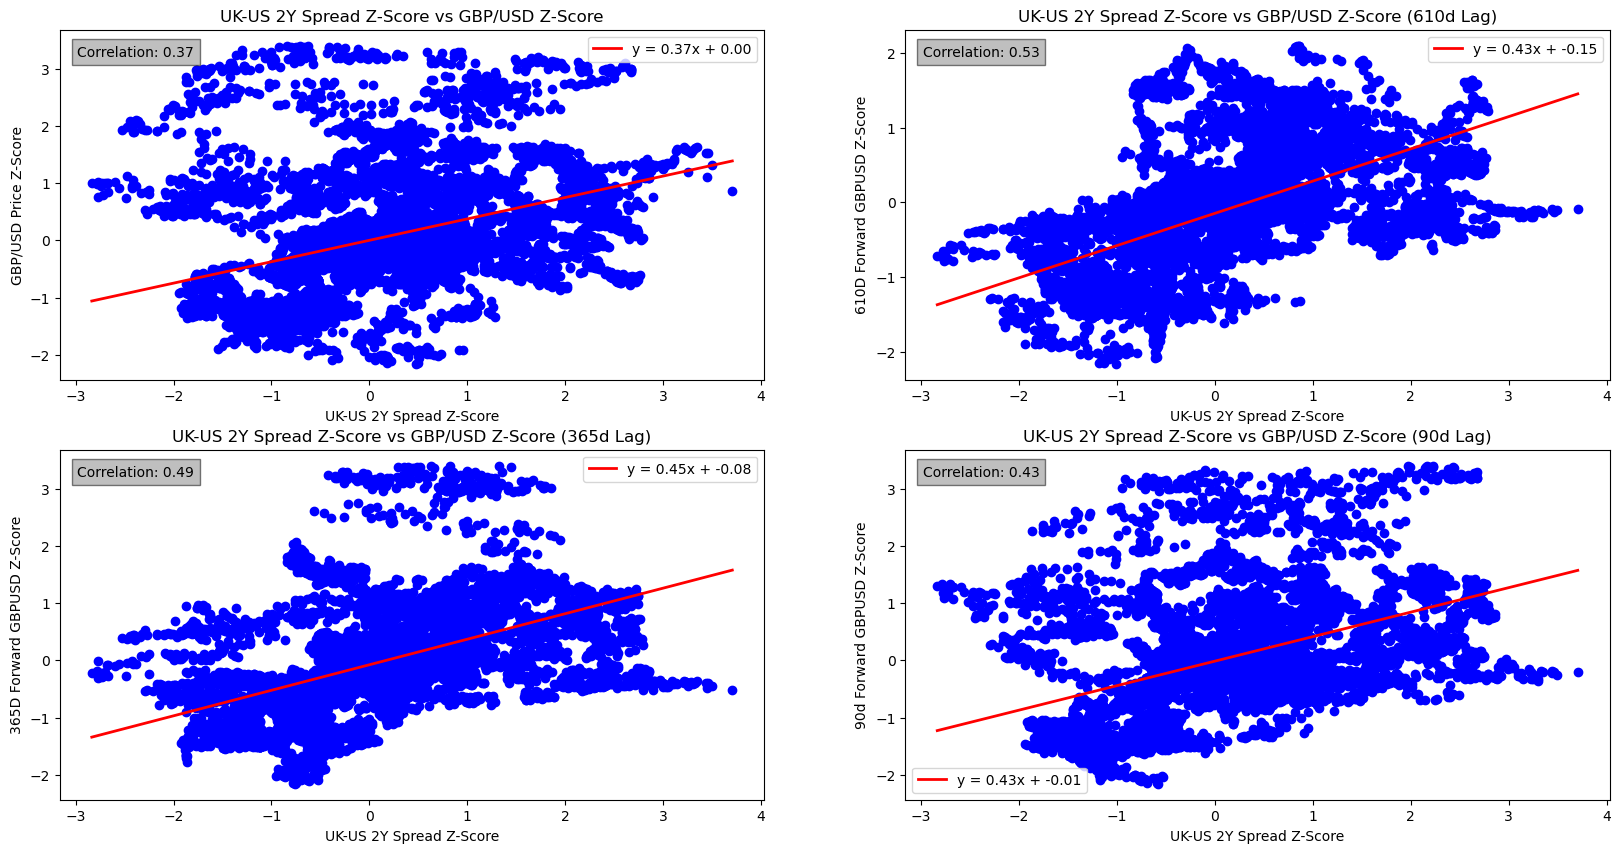

In [343]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

# Spread vs Returns
axs[0, 0].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score", fontsize=12)
axs[0, 0].scatter(spread["spread_z_score"], gbpusd["price_z_score"], color="blue")

axs[0, 0].set_xlabel("UK-US 2Y Spread Z-Score")
axs[0, 0].set_ylabel("GBP/USD Price Z-Score")

x_line = np.linspace(min(spread["spread_z_score"]), max(spread["spread_z_score"]), 100)
y_line = contemporaneous_regression.params.iloc[0] + contemporaneous_regression.params.iloc[1] * x_line
axs[0, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {contemporaneous_regression.params.iloc[1]:.2f}x + {contemporaneous_regression.params.iloc[0]:.2f}")

corr = spread["spread_z_score"].corr(gbpusd["price_z_score"])
axs[0, 0].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[0, 0].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[0, 0].legend()

# Spread vs 610d Forward Returns
axs[0, 1].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (610d Lag)", fontsize=12)
axs[0, 1].scatter(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()], color="blue")

axs[0, 1].set_xlabel("UK-US 2Y Spread Z-Score")
axs[0, 1].set_ylabel("610D Forward GBPUSD Z-Score")

x_line = np.linspace(min(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()]), max(spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()]), 100)
y_line = six10_day_regression.params.iloc[0] + six10_day_regression.params.iloc[1] * x_line
axs[0, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {six10_day_regression.params.iloc[1]:.2f}x + {six10_day_regression.params.iloc[0]:.2f}")

corr = spread["610d_spread_z_score"][spread["610d_spread_z_score"].notna()].corr(gbpusd["price_z_score"][spread["610d_spread_z_score"].notna()])
axs[0, 1].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[0, 1].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[0, 1].legend()

# Spread vs 365d Forward Returns
axs[1, 0].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (365d Lag)", fontsize=12)
axs[1, 0].scatter(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()], color="blue")

axs[1, 0].set_xlabel("UK-US 2Y Spread Z-Score")
axs[1, 0].set_ylabel("365D Forward GBPUSD Z-Score")

x_line = np.linspace(min(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()]), max(spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()]), 100)
y_line = three65_day_regression.params.iloc[0] + three65_day_regression.params.iloc[1] * x_line
axs[1, 0].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {three65_day_regression.params.iloc[1]:.2f}x + {three65_day_regression.params.iloc[0]:.2f}")

corr = spread["365d_spread_z_score"][spread["365d_spread_z_score"].notna()].corr(gbpusd["price_z_score"][spread["365d_spread_z_score"].notna()])
axs[1, 0].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[1, 0].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[1, 0].legend()

# Spread vs 90d Forward Returns
axs[1, 1].set_title("UK-US 2Y Spread Z-Score vs GBP/USD Z-Score (90d Lag)", fontsize=12)
axs[1, 1].scatter(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()], gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()], color="blue")

axs[1, 1].set_xlabel("UK-US 2Y Spread Z-Score")
axs[1, 1].set_ylabel("90d Forward GBPUSD Z-Score")

x_line = np.linspace(min(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()]), max(spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()]), 100)
y_line = ninety_day_regression.params.iloc[0] + ninety_day_regression.params.iloc[1] * x_line
axs[1, 1].plot(x_line, y_line, color="red", linewidth=2, label=f"y = {ninety_day_regression.params.iloc[1]:.2f}x + {ninety_day_regression.params.iloc[0]:.2f}")

corr = spread["90d_spread_z_score"][spread["90d_spread_z_score"].notna()].corr(gbpusd["price_z_score"][spread["90d_spread_z_score"].notna()])
axs[1, 1].text(0.025, 0.925, f"Correlation: {corr:.2f}", transform=axs[1, 1].transAxes, bbox=dict(facecolor="grey", alpha=0.5))

axs[1, 1].legend()

### Analysis & Next Steps

**Analysis**
- When the UK-US 2-year yield spread is wide (UK yields high relative to the US), GBP/USD tends to be elevated or to rise over the following 90-610 days. That’s the kernel of a carry-linked expectation signal.

**Limitations**
- Spurious Correlation: Two non-stationary distributions
- Global Z-Scores (not rolling)

**Conclusion**
- Shows there might be something so worth investigating but is no means a signal of reliable predictability


**Next Steps**
- X


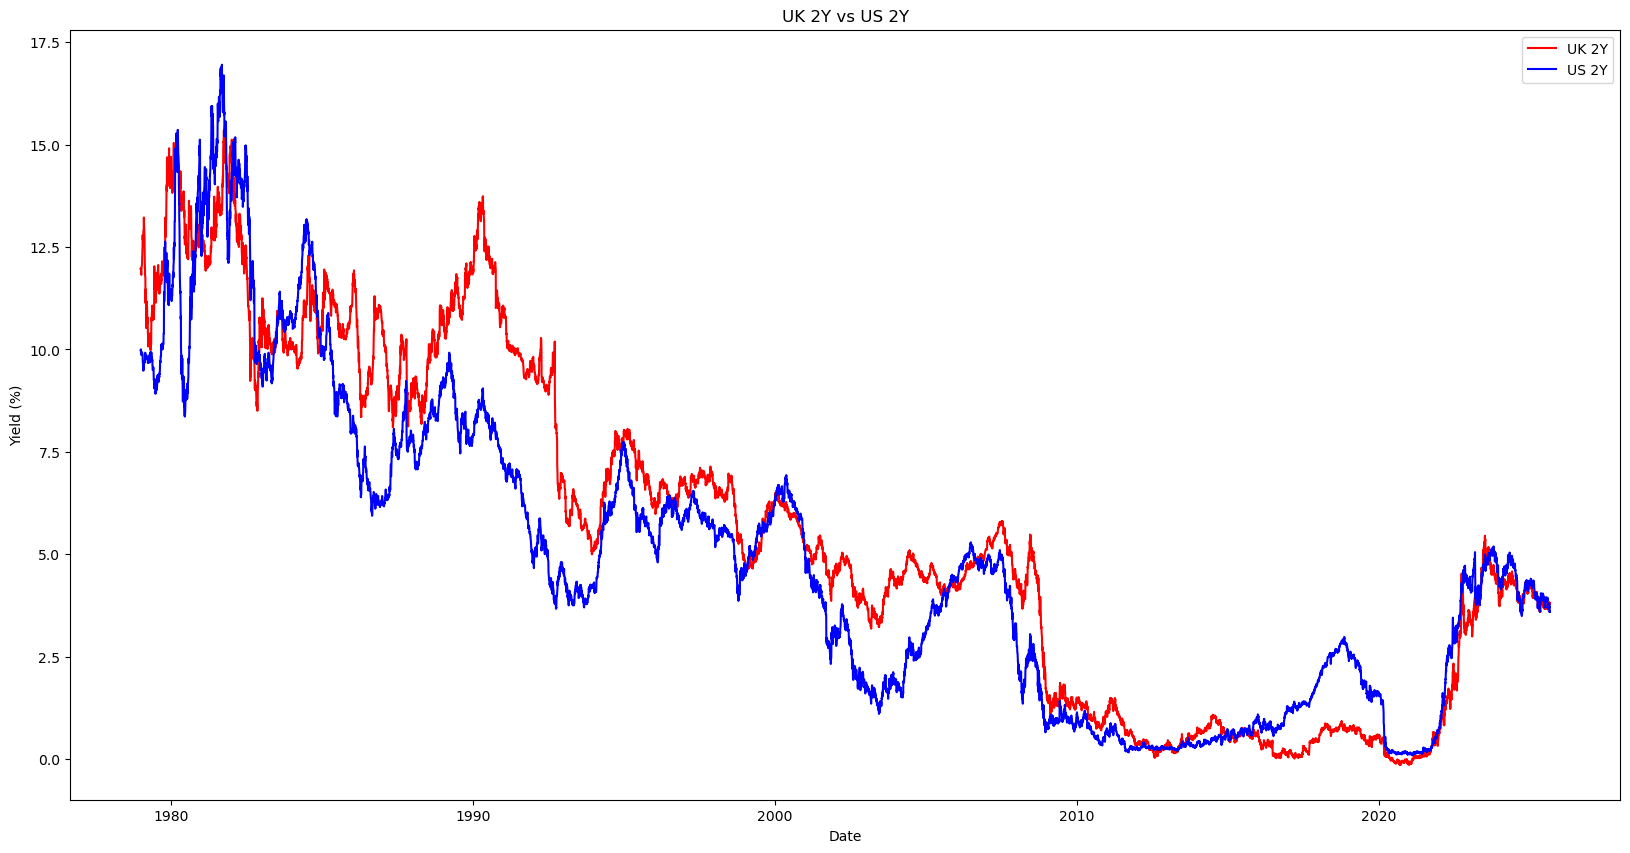

In [344]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))

axs.set_title("UK 2Y vs US 2Y", fontsize=12)
axs.plot(spread["uk_2y"], label="UK 2Y", color="red")
axs.plot(spread["us_2y"], label="US 2Y", color="blue")

axs.set_xlabel("Date")
axs.set_ylabel("Yield (%)")
axs.legend()

## Backtesting: Spread Z-Score Signal

In [345]:
horizon = 90

### Signal & Positions

In [346]:
signal_t = spread["spread_z_score"].copy(deep=True)

In [347]:
signal_t[(signal_t > -1) & (signal_t < 1)] = 0
signal_t[signal_t > 1] = 1
signal_t[signal_t < -1] = -1

In [348]:
signal_t.value_counts()

spread_z_score
 0.0    8720
 1.0    1830
-1.0    1625
Name: count, dtype: int64

In [349]:
position = signal_t.shift(1)

### Computing Returns

In [350]:
ninety_day_returns = (gbpusd["gbp_usd_noon_rate"].shift(-horizon) / gbpusd["gbp_usd_noon_rate"]) - 1
position = position[ninety_day_returns.notna() & position.notna()]
ninety_day_returns = ninety_day_returns[ninety_day_returns.notna() & position.notna()]

In [351]:
trade_dates = np.arange(0, len(position), horizon)

In [352]:
positions = position.iloc[trade_dates]

In [353]:
returns = ninety_day_returns.iloc[trade_dates]

### Calculate Gross PnL

In [354]:
gross_90d_pnl = positions * returns

### TX Costs

In [355]:
trades = positions.diff().abs()
costs = trades * 0.0001

### Net PnL


In [356]:
net_90d_pnl = gross_90d_pnl - costs

### Cumulative Returns & Equity Curve

In [357]:
cumulative_return = (1 + net_90d_pnl).cumprod()

capital = 100
cumulative_capital = capital * cumulative_return

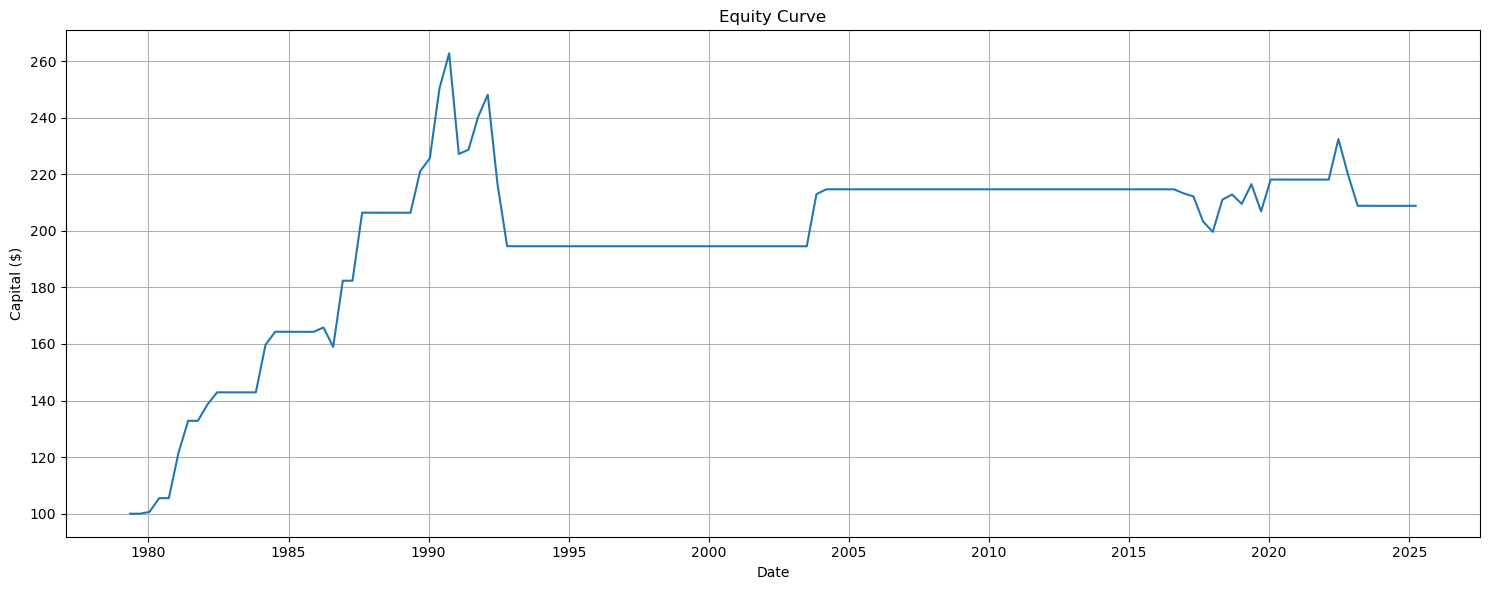

In [358]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

ax.plot(cumulative_capital)
ax.set_title("Equity Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Capital ($)")
ax.grid(True)

plt.tight_layout()
plt.show()

In [359]:
total_return = cumulative_return.iloc[-1] - 1
print(f"Total Return: {total_return * 100:.2f}%")

Total Return: 108.83%


In [360]:
total_pnl = cumulative_capital.iloc[-1] - capital
print(f"Total PnL: £{total_pnl:.2f}")

Total PnL: £108.83


### Annualized Return

In [361]:
backtest_days = len(signal_t)

annualized_return = (1 + total_return) ** (252 / backtest_days) - 1
print(f"Annualized Return: {annualized_return * 100:.2f}%")

Annualized Return: 1.54%


### Annualized Volatility

In [362]:
annualized_volatility = returns.std() * np.sqrt((252 / 90))
print(f"Annualized Volatility: {annualized_volatility * 100:.2f}%")

Annualized Volatility: 10.15%


### Sharpe Ratio

In [363]:
risk_free_rate = 0

sharpe = annualized_return - risk_free_rate / annualized_volatility
sharpe

np.float64(0.01535815084193426)

### Max Drawdown

In [364]:
rolling_max = cumulative_capital.cummax()

drawdown = (cumulative_capital / rolling_max) - 1

max_drawdown = drawdown.min()

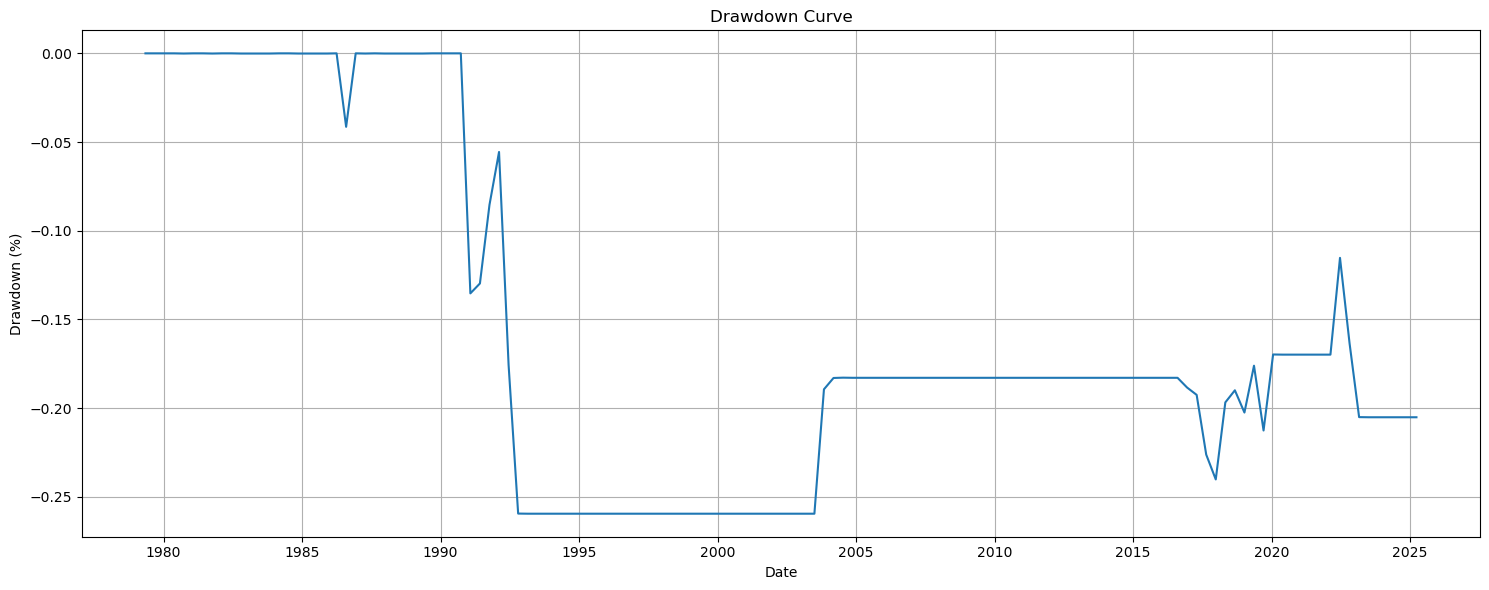

In [365]:
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

ax.plot(drawdown)
ax.set_title("Drawdown Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.grid(True)

plt.tight_layout()
plt.show()

### Hit ratio

In [366]:
win_rate = (returns > 0).mean() * 100

print(f"Win Rate: {win_rate:.2f}%")

Win Rate: 55.56%
